# Simple Linear Regression — From Scratch

Linear regression is one of the most fundamental techniques in statistics and machine learning.
Given a set of data points, we want to find the straight line that **best fits** the data.

## Key Concepts

- **Dependent variable** ($Y$): the value we want to predict (e.g., salary).
- **Independent variable** ($X$): the feature we use to predict $Y$ (e.g., years of experience).
- **Model**: $Y = b_0 + b_1 X + \varepsilon$, where $b_0$ is the intercept, $b_1$ is the slope, and $\varepsilon$ is random noise.

## Assumptions of Linear Regression

1. **Linearity** — the relationship between $X$ and $Y$ is linear.
2. **Independence** — observations are independent of each other.
3. **Homoscedasticity** — the variance of the errors is constant.
4. **Normality** — the errors are normally distributed (important for inference, less so for prediction).

## Roadmap

1. Explore the data (scatter plots, correlation).
2. Compute mean, variance, and covariance from scratch.
3. Derive the OLS coefficients.
4. Make predictions and evaluate with RMSE.
5. Understand the ANOVA decomposition and $R^2$.

---
## 1. Exploratory Data Analysis

We start by visualizing the relationship between working experience and salary.
A scatter plot is the natural first step for any regression problem.

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

1. The relationship between working experience and salary?


In [46]:
experience=[1,2,3,4,5,6,7,8,9,10,2,2,3,3,3,2,4,5,5,2]
salary    =[5000,7000,8000,10000,15000,18000,19000,20000,16000,30000,12000,6000,8000,5500,9000,7800,9200,14000,16000,8000]

list_of_tuples=list(zip(experience,salary))
df=pd.DataFrame(list_of_tuples,columns=['experience','salary'])
df

,experience,salary
0,1,5000
1,2,7000
2,3,8000
3,4,10000
4,5,15000
5,6,18000
6,7,19000
7,8,20000
8,9,16000
9,10,30000


In [47]:
df.describe()

,experience,salary
count,20.000000,20.000000
mean,4.300000,12175.000000
std,2.556725,6308.379974
min,1.000000,5000.000000
25%,2.000000,7950.000000
50%,3.500000,9600.000000
75%,5.250000,16000.000000
max,10.000000,30000.000000


In [48]:
df.corr()

,experience,salary
experience,1.000000,0.906682
salary,0.906682,1.000000


<function matplotlib.pyplot.show(*args, **kw)>

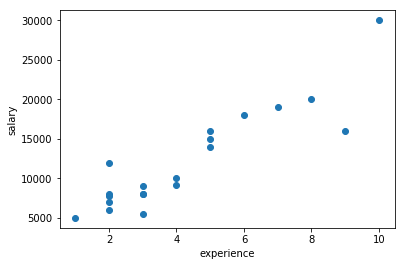

In [49]:
plt.scatter(df.experience,df.salary)
plt.xlabel('experience')
plt.ylabel('salary')
plt.show

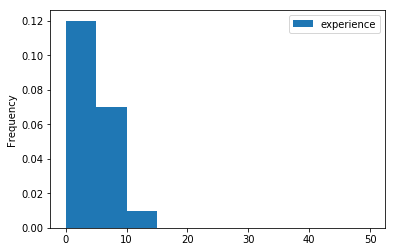

In [50]:
df.plot(kind="hist",y="experience",bins=10 ,range=(0,50),density= True)

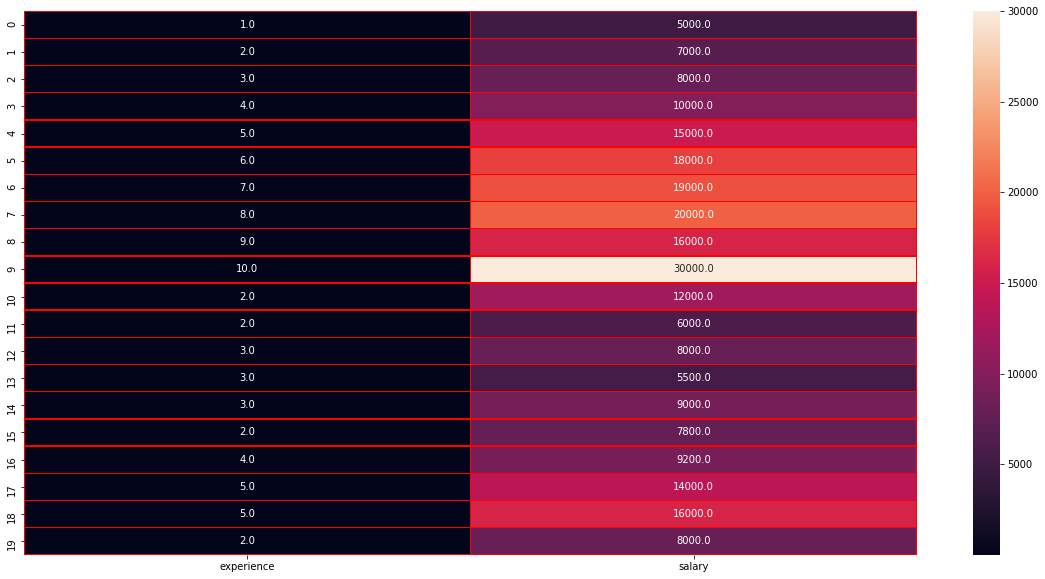

In [51]:
f, ax =plt.subplots(figsize=(20,10))
sns.heatmap(df,annot=True,linewidths=0.5,linecolor="red",fmt=".1f",ax=ax)
plt.show()

---
## 2. Statistical Foundations

Before fitting a line we need three building blocks:

### 2.1 Covariance

Measures the *linear association* between two variables:

$$ \text{Cov}(X,Y) = \frac{\sum_{i=1}^{n}(X_i - \bar{X})(Y_i - \bar{Y})}{n-1} $$

Positive → $X$ and $Y$ tend to move together; negative → they move in opposite directions.

### 2.2 Variance

$$ \text{Var}(X) = \frac{\sum_{i=1}^{n}(X_i - \bar{X})^2}{n-1} $$

### 2.3 Correlation

Covariance normalized to $[-1, 1]$:

$$ r = \frac{\text{Cov}(X,Y)}{\sigma_X \sigma_Y} $$

Because covariance can range from $-\infty$ to $+\infty$, correlation is usually preferred for
interpretation.

In [52]:
# First , Let's calculate the mean!
def calculate_mean(a_list_of_values):
    mean=sum(a_list_of_values)/float(len(a_list_of_values))
    return mean

In [53]:
# Then , Let's calculate the variance!
def calculate_variance(a_list_of_values,mean):
    variance_sum=sum((x-mean)**2 for x in a_list_of_values)
    variance=variance_sum/(len(a_list_of_values)-1)
    return variance

In [54]:
mean_experience=calculate_mean(experience)
print(mean_experience)
variance_experience=calculate_variance(experience,mean_experience)
print(variance_experience)

4.3
6.536842105263156


In [55]:
mean_salary=calculate_mean(salary)
print(mean_salary)
variance_salary=calculate_variance(salary,mean_salary)
print(variance_salary)

12175.0
39795657.89473684


In [56]:
# And then we calculate the Covariance

def calculate_covariance(a_list_of_Xs,the_mean_of_Xs,a_list_of_Ys,the_mean_of_Ys):
    cov_sum=0
    for i in range(len(a_list_of_Xs)):
        cov_sum+=(a_list_of_Xs[i]-the_mean_of_Xs)*(a_list_of_Ys[i]-the_mean_of_Ys)
    the_covariance=cov_sum/(len(a_list_of_Xs)-1)
    return the_covariance

In [57]:
df.cov()

,experience,salary
experience,6.536842,1.462368e+04
salary,14623.684211,3.979566e+07


In [58]:
covariance_of_experience_and_salary=calculate_covariance(experience,mean_experience,salary,mean_salary)
print(covariance_of_experience_and_salary)

14623.684210526315


In [59]:
# Let's calculate standard deviation!

def calculate_the_standard_deviation(a_list_values):
    the_mean_of_the_list_values=sum(a_list_values)/float(len(a_list_values))
    variance=sum([(a_list_values[i]-the_mean_of_the_list_values)**2 for i in range(len(a_list_values)) ]) / float(len(a_list_values)-1)
    return variance**0.5


In [60]:
a=[1,2,3,4,5,6,7,8,9,10]
calculate_the_standard_deviation(a)

3.0276503540974917

In [61]:
import pandas as pd
b=np.array(a)
b.std()

2.8722813232690143

In [62]:
# Let's calculate the correlation!

def calculate_the_correlation(a_list_of_Xs,the_mean_of_Xs,a_list_of_Ys,the_mean_of_Ys):
    X_std=calculate_the_standard_deviation(a_list_of_Xs)
    Y_std=calculate_the_standard_deviation(a_list_of_Ys)
    X_Y_Cov=calculate_covariance(a_list_of_Xs,the_mean_of_Xs,a_list_of_Ys,the_mean_of_Ys)
    
    Corr=(X_Y_Cov)/(X_std*Y_std)
    return Corr

    

In [63]:
calculate_the_correlation(experience,mean_experience,salary,mean_salary)

0.9066819256731471

In [64]:
df.corr()

,experience,salary
experience,1.000000,0.906682
salary,0.906682,1.000000


---
## 3. Ordinary Least Squares (OLS)

OLS finds the line that minimizes the sum of squared residuals.

### Coefficient Formulas

$$ b_1 = \frac{\text{Cov}(X,Y)}{\text{Var}(X)} = \frac{\sum(X_i - \bar{X})(Y_i - \bar{Y})}{\sum(X_i - \bar{X})^2} $$

$$ b_0 = \bar{Y} - b_1 \bar{X} $$

### Interpreting the Coefficients

- $b_0$ (intercept): the predicted value of $Y$ when $X = 0$.
- $b_1$ (slope): for each unit increase in $X$, $Y$ changes by $b_1$ units on average.

Make Prediction: Use one variable to make prediction about another

dependent variable:Y

independent variable:X

William Inc index 

![lr.png](attachment:lr.png)

Oridinary Least Square(OLS)

![OLS.png](attachment:OLS.png)

$b1=\frac{Cov(X,Y)}{Variance(X,X)}=\frac{\sum_{i=1}^{n}(X_i-\overline X)(Y_i- \overline Y)}{\sum_{i=1}^{n}(X_i-\overline X)(X_i-\overline X)}$
$b0=\overline Y -b1\overline X$

In [65]:
def calculate_the_coefficients(dataset):
    x=[row[0] for row in dataset]
    y=[row[1] for row in dataset]
    x_mean,y_mean=calculate_mean(x),calculate_mean(y)
    b1=calculate_covariance(x,x_mean,y,y_mean)/calculate_variance(x,x_mean)
    b0=y_mean-b1*x_mean
    
    return [b0,b1]


In [66]:
list_of_tuples

[(1, 5000),
 (2, 7000),
 (3, 8000),
 (4, 10000),
 (5, 15000),
 (6, 18000),
 (7, 19000),
 (8, 20000),
 (9, 16000),
 (10, 30000),
 (2, 12000),
 (2, 6000),
 (3, 8000),
 (3, 5500),
 (3, 9000),
 (2, 7800),
 (4, 9200),
 (5, 14000),
 (5, 16000),
 (2, 8000)]

In [67]:
list_of_lists=[list(elem) for elem in list_of_tuples]
list_of_lists

[[1, 5000],
 [2, 7000],
 [3, 8000],
 [4, 10000],
 [5, 15000],
 [6, 18000],
 [7, 19000],
 [8, 20000],
 [9, 16000],
 [10, 30000],
 [2, 12000],
 [2, 6000],
 [3, 8000],
 [3, 5500],
 [3, 9000],
 [2, 7800],
 [4, 9200],
 [5, 14000],
 [5, 16000],
 [2, 8000]]

In [68]:
b0,b1=calculate_the_coefficients(list_of_lists)
b1


2237.1175523349443

y=2555+2237X

---
## 4. Making Predictions & Evaluating with RMSE

With $b_0$ and $b_1$ in hand, we predict $\hat{Y} = b_0 + b_1 X$ for each test point.
We measure quality using **Root Mean Squared Error**:

$$ \text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(\hat{Y}_i - Y_i)^2} $$

Lower RMSE = better fit.

![rou.png](attachment:rou.png)

In [69]:
def simple_linear_regression(training_data,testing_data):
    predictions=[]
    b0,b1=calculate_the_coefficients(training_data)
    for row in testing_data:
        y=b0+b1*row[0]
        predictions.append(y)
    return predictions
    
    

In [70]:
from math import sqrt
def calculate_the_RMSE(predicted_data,actual_data):
    the_sum_of_error=0
    for i in range(len(actual_data)):
        prediction_error=predicted_data[i]-actual_data[i]
        the_sum_of_error += (prediction_error**2)
    RMSE=sqrt(the_sum_of_error/float(len(actual_data)))
    return RMSE

In [71]:
data_to_be_put_into_the_model=[]
for row in list_of_lists:
    row_copy=list(row)
    row_copy[-1]=None
    data_to_be_put_into_the_model.append(row_copy)
data_to_be_put_into_the_model

[[1, None],
 [2, None],
 [3, None],
 [4, None],
 [5, None],
 [6, None],
 [7, None],
 [8, None],
 [9, None],
 [10, None],
 [2, None],
 [2, None],
 [3, None],
 [3, None],
 [3, None],
 [2, None],
 [4, None],
 [5, None],
 [5, None],
 [2, None]]

In [72]:
predictions=simple_linear_regression(list_of_lists,data_to_be_put_into_the_model)
predictions

[4792.512077294685,
 7029.629629629629,
 9266.747181964573,
 11503.864734299517,
 13740.982286634462,
 15978.099838969405,
 18215.21739130435,
 20452.334943639296,
 22689.45249597424,
 24926.570048309186,
 7029.629629629629,
 7029.629629629629,
 9266.747181964573,
 9266.747181964573,
 9266.747181964573,
 7029.629629629629,
 11503.864734299517,
 13740.982286634462,
 13740.982286634462,
 7029.629629629629]

In [73]:
actual_data=[row[-1] for row in list_of_lists]
actual_data

[5000,
 7000,
 8000,
 10000,
 15000,
 18000,
 19000,
 20000,
 16000,
 30000,
 12000,
 6000,
 8000,
 5500,
 9000,
 7800,
 9200,
 14000,
 16000,
 8000]

In [76]:
def how_good_is_our_model(dataset,some_model_to_be_evaluated):
    test_data=[]
    for row in dataset:
        row_copy=list(row)
        row_copy[-1]=None
        test_data.append(row_copy)
    predict_data=some_model_to_be_evaluated(dataset,test_data)
    print(predict_data)
    actual_data=[row[-1] for row in dataset]
    print(actual_data)
    RMSE=calculate_the_RMSE(predict_data,actual_data)
    return RMSE
    

In [77]:
result=how_good_is_our_model(list_of_lists,simple_linear_regression)
print(result)

[4792.512077294685, 7029.629629629629, 9266.747181964573, 11503.864734299517, 13740.982286634462, 15978.099838969405, 18215.21739130435, 20452.334943639296, 22689.45249597424, 24926.570048309186, 7029.629629629629, 7029.629629629629, 9266.747181964573, 9266.747181964573, 9266.747181964573, 7029.629629629629, 11503.864734299517, 13740.982286634462, 13740.982286634462, 7029.629629629629]
[5000, 7000, 8000, 10000, 15000, 18000, 19000, 20000, 16000, 30000, 12000, 6000, 8000, 5500, 9000, 7800, 9200, 14000, 16000, 8000]
2593.5919887651553


---
## 5. ANOVA Decomposition & $R^2$

The **Analysis of Variance (ANOVA)** table decomposes total variability into explained and unexplained parts.

- **TSS** (Total Sum of Squares): total variability of $Y$ around its mean.
- **RSS / SSR** (Regression Sum of Squares): variability *explained* by the model.
- **ESS / SSE** (Error Sum of Squares): variability *not* explained (residuals).

The **Coefficient of Determination** $R^2$:

$$ R^2 = \frac{\text{SSR}}{\text{SST}} = 1 - \frac{\text{SSE}}{\text{SST}} $$

- $R^2 = 1$: perfect fit.
- $R^2 = 0$: model explains nothing beyond the mean.

For simple linear regression, $R^2 = r^2$ (the square of the Pearson correlation).

![ANOVA_TABLE.jpg](attachment:ANOVA_TABLE.jpg)

ANOVA(Analysis of Variance) Table![ATypicalANOVA.png](attachment:ATypicalANOVA.png)

![ANOVAPIC.png](attachment:ANOVAPIC.png)

$TSS = (Y_1 - \overline Y)^2 + (Y_2 - \overline Y)^2+ (Y_3 - \overline Y)^2 +.......$<br>
$RSS = (\hat Y_1 - \overline Y)^2 + (\hat Y_2 - \overline Y)^2+ (\hat Y_3 - \overline Y)^2......$<br>
$SSE = (Y_1-\hat Y_1)^2 +(Y_2-\hat Y_2)^2 +(Y_3-\hat Y_3)^2+ ......$

$R^2$ Coefficient of Determination<br>
$R^2 = \frac{SSR(Explained \; Variantion)}{SST(Total \;Variation)}= 1- \frac{ESS(Unexplained \;Variation)}{SST(Total\;Variation)}$

---
## 6. Regularization

### What Is Overfitting?

When a model fits the training data *too well* — capturing noise rather than the
underlying pattern — it **overfits**. An overfit model has low training error but
high test error. Regularization combats this by adding a **penalty term** to the
loss function that discourages overly complex (large) coefficients.

### L2 Regularization — Ridge Regression

Ridge Regression adds the **squared magnitude** of coefficients to the ordinary
least-squares loss:

$$J_{\text{Ridge}}(\mathbf{w}) = \sum_{i=1}^{n}\bigl(y_i - \hat{y}_i\bigr)^2 + \lambda \sum_{j=1}^{p} w_j^2$$

where $\lambda \ge 0$ controls the regularization strength. Larger $\lambda$
shrinks all coefficients toward zero but never exactly to zero.

### L1 Regularization — Lasso Regression

Lasso Regression uses the **absolute value** of coefficients instead:

$$J_{\text{Lasso}}(\mathbf{w}) = \sum_{i=1}^{n}\bigl(y_i - \hat{y}_i\bigr)^2 + \lambda \sum_{j=1}^{p} |w_j|$$

The L1 penalty can drive some coefficients to **exactly zero**, effectively
performing **feature selection**.

### Elastic Net

Elastic Net combines both penalties:

$$J_{\text{ElasticNet}}(\mathbf{w}) = \sum_{i=1}^{n}\bigl(y_i - \hat{y}_i\bigr)^2 + \lambda_1 \sum_{j=1}^{p} |w_j| + \lambda_2 \sum_{j=1}^{p} w_j^2$$

### When to Use Which?

| Scenario | Recommended |
|---|---|
| Many features with small, distributed effects | **Ridge** — shrinks all coefficients evenly |
| Sparse model expected (few relevant features) | **Lasso** — sets irrelevant coefficients to zero |
| Correlated features + sparsity desired | **Elastic Net** — balances both benefits |

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Ridge Regression from scratch using Gradient Descent ---

def ridge_regression_gd(X, y, learning_rate=0.01, lam=1.0, n_epochs=1000):
    """Train a Ridge Regression model via gradient descent.

    Parameters
    ----------
    X : np.ndarray, shape (n, p)
    y : np.ndarray, shape (n,)
    learning_rate : float
    lam : float – regularization strength (λ)
    n_epochs : int

    Returns
    -------
    w : np.ndarray, shape (p,) – learned weights
    b : float – learned bias (intercept)
    """
    n, p = X.shape
    w = np.zeros(p)
    b = 0.0

    for _ in range(n_epochs):
        y_hat = X @ w + b
        error = y_hat - y                    # (n,)

        dw = (2 / n) * (X.T @ error) + 2 * lam * w
        db = (2 / n) * np.sum(error)

        w -= learning_rate * dw
        b -= learning_rate * db

    return w, b

# Small sample dataset
np.random.seed(42)
X_sample = 2 * np.random.rand(30, 1)
y_sample = 4 + 3 * X_sample.squeeze() + np.random.randn(30)

# Fit with different λ values
lambdas = [0.0, 0.5, 5.0, 50.0]
plt.figure(figsize=(10, 6))
plt.scatter(X_sample, y_sample, color='black', zorder=5, label='Data')

X_plot = np.linspace(0, 2, 100).reshape(-1, 1)
for lam in lambdas:
    w, b = ridge_regression_gd(X_sample, y_sample, learning_rate=0.1, lam=lam, n_epochs=2000)
    y_plot = X_plot @ w + b
    plt.plot(X_plot, y_plot, label=f'λ = {lam}  (w={w[0]:.2f}, b={b:.2f})')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Ridge Regression — Effect of λ on the Fit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Ridge vs Lasso — Side-by-Side Comparison

| Property | Ridge (L2) | Lasso (L1) |
|---|---|---|
| **Penalty term** | $\lambda \sum w_j^2$ | $\lambda \sum \lvert w_j \rvert$ |
| **Coefficient shrinkage** | Shrinks toward zero, never exactly zero | Can shrink coefficients to **exactly** zero |
| **Feature selection** | No — keeps all features | Yes — eliminates irrelevant features |
| **Multicollinearity** | Handles well — distributes weight among correlated features | May arbitrarily pick one of correlated features |
| **Solution uniqueness** | Always unique (strictly convex) | May not be unique when $p > n$ |
| **Gradient** | $2\lambda w_j$ (smooth everywhere) | $\lambda \operatorname{sign}(w_j)$ (non-smooth at 0) |
| **Best when** | Many small, distributed effects | Few important features expected |